#Задание первое
Перед выполнением задания скачайте .zip-архив по следующей ссылке:
[Ссылка на файл](https://drive.google.com/file/d/1E8c2EGnznSQvb4LdN3mDFgjl3ue6gAQc/view?usp=sharing)

Поместите файл в файловое хранилище слева:

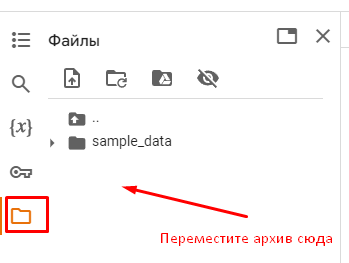

Создайте папку при помощи консольной команды Colab ("mkdir")

При помощи консольной команды "unzip" в Colab распакуйте данный архив в созданную папку

In [ ]:
!mkdir folder

mkdir: cannot create directory ‘folder’: File exists


In [ ]:
!unzip input_data.zip -d folder

Archive:  input_data.zip
replace folder/input_data/119h199gjj92.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

#Задание второе

В созданной папке после разархивации .zip-архива присутствуют файлы различных расширений. Файлы с одним расширением имеют одинаковый формат.

1. Воспользуйтесь библиотекой «os» и выведете, какие расширения файлов есть в папке и сколько их;
2. Создайте три массива: для дробных чисел, для целых неотрицательных чисел, для целых отрицательных чисел;
3. Прочитайте все файлы, распределите все числа из них по трем массивам. Для каждого расширения необходимо создать свой обработчик, так как файлы с различными расширениями имеют различный формат.
4. Создайте массив JSON, в котором будет храниться информация о заданных наборах чисел: тип чисел, сумма чисел, максимальное, минимальное и количество чисел. Выведете на экран получившийся json через print. Используйте библиотеку «json». Пример массива JSON:

[
{"type":"целые неотрицательные",

"count":15,

"max":332},

{...},

]

5. Созданный на шаге 4 массив запишите в файл под названием «numbers.json».

In [ ]:
import csv
import json
import os

#Решение
#1
from collections import Counter

path = ("/content/folder/input_data")
files = os.listdir(path)
extensions = []

for f in files:
  full_path = os.path.join(path, f)
  if os.path.isfile(full_path):
        ext = os.path.splitext(f)[1]
        extensions.append(ext)

counter = Counter(extensions)

for ext, count in counter.items():
    print(f"{ext}: {count}")

#2
float_numbers = []
positive_int_numbers = []
negative_int_numbers = []

#3
def classify_number(num):
    if isinstance(num, float) and not num.is_integer():
        float_numbers.append(num)
    else:
        num = int(num)
        if num >= 0:
            positive_int_numbers.append(num)
        else:
            negative_int_numbers.append(num)


def process_txt(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()

        items = content.replace(",", " ").split()
        for item in items:
            num = float(item)
            classify_number(num)


def process_csv(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.reader(f, delimiter="?")

        for row in reader:
            for item in row:
                num = float(item)
                classify_number(num)


def process_json(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

        for item in data:
            classify_number(float(item["value"]))
#4
handlers = {
    ".txt": process_txt,
    ".csv": process_csv,
    ".json": process_json
}

for filename in os.listdir(path):
    filepath = os.path.join(path, filename)

    if os.path.isfile(filepath):
        ext = os.path.splitext(filename)[1]

        if ext in handlers:
            handlers[ext](filepath)


def get_stats(arr, number_type):
    if len(arr) == 0:
        return {
            "type": number_type,
            "count": 0,
            "sum": 0,
            "max": None,
            "min": None
        }

    return {
        "type": number_type,
        "count": len(arr),
        "sum": sum(arr),
        "max": max(arr),
        "min": min(arr)
    }


result = [
    get_stats(positive_int_numbers, "целые неотрицательные"),
    get_stats(negative_int_numbers, "целые отрицательные"),
    get_stats(float_numbers, "дробные")
]

print(json.dumps(result, ensure_ascii=False, indent=4))

#5
with open("numbers.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=4)

.csv: 255
.txt: 112
.json: 23
[
    {
        "type": "целые неотрицательные",
        "count": 6550,
        "sum": 195673,
        "max": 100,
        "min": 1
    },
    {
        "type": "целые отрицательные",
        "count": 0,
        "sum": 0,
        "max": null,
        "min": null
    },
    {
        "type": "дробные",
        "count": 12600,
        "sum": -2795.289783117241,
        "max": 49.99899978442191,
        "min": -49.96615077835693
    }
]


#Задание третье

1. Сделайте GET-запрос к ресурсу https://jsonplaceholder.typicode.com/posts
2. Сохраните полученную с ресурса информацию в переменную типа pd.DataFrame (библиотека pandas);
3. Выведете на экран, у каких пользователей сколько постов в формате: %UserID% - %Количество постов%;
4. Найдите среднюю длину поста;
5. Найдите среднюю, максимальную и минимальную длину поста для каждого пользователя;
6. Выведете все посты, в которых есть слово «aspernatur»;

In [ ]:
import pandas as pd
import requests

#Решение

# 1
url = "https://jsonplaceholder.typicode.com/posts"

response = requests.get(url)
data = response.json()

# 2
df = pd.DataFrame(data)

# 3
posts_count = df.groupby("userId").size()

for user_id, count in posts_count.items():
    print(f"{user_id} - {count}")


# 4
df["post_length"] = df["body"].apply(len)

average_length = df["post_length"].mean()

print("Средняя длина поста:", average_length)


# 5
stats = df.groupby("userId")["post_length"].agg(["mean", "max", "min"])

print(stats)

# 6
filtered_posts = df[
    df["title"].str.contains("aspernatur", case=False, na=False) |
    df["body"].str.contains("aspernatur", case=False, na=False)
]

print(filtered_posts)

1 - 10
2 - 10
3 - 10
4 - 10
5 - 10
6 - 10
7 - 10
8 - 10
9 - 10
10 - 10
Средняя длина поста: 160.64
         mean  max  min
userId                 
1       164.5  206  129
2       162.9  225  111
3       153.8  190  128
4       182.3  212  136
5       162.5  193  113
6       147.0  197  122
7       163.5  218  127
8       160.6  196  102
9       154.6  198  106
10      154.7  215  109
    userId  id                                              title  \
5        1   6                 dolorem eum magni eos aperiam quia   
16       2  17  fugit voluptas sed molestias voluptatem provident   
35       4  36      fuga nam accusamus voluptas reiciendis itaque   
38       4  39        eos dolorem iste accusantium est eaque quam   
48       5  49  laborum non sunt aut ut assumenda perspiciatis...   
61       7  62                               beatae enim quia vel   
62       7  63  voluptas blanditiis repellendus animi ducimus ...   
66       7  67        aliquid eos sed fuga est maxime repelle